# Basic Sales Analysis using SQLite and Python
This project demonstrates how to:
- Create SQLite database
- Run SQL queries
- Load results into Pandas
- Visualize revenue using Matplotlib

In [49]:
# importing the libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [51]:
# This creates the database file in your current folder.
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

In [52]:
#create a table for the database
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

conn.commit()

In [53]:
# Clear old data
cursor.execute("DELETE FROM sales")


In [54]:
#inserting the values into table
cursor.executemany("""
INSERT INTO sales (product, quantity, price)
VALUES (?, ?, ?)
""", [
    ("Laptop", 5, 50000),
    ("Mobile", 10, 20000),
    ("Tablet", 7, 15000),
    ("Laptop", 3, 50000),
    ("Mobile", 5, 20000),
    ("Tablet", 4, 15000),
    ("Headphones", 12, 2000),
    ("Headphones", 8, 2000),
    ("Smartwatch", 6, 10000),
    ("Smartwatch", 4, 10000),
    ("Camera", 2, 40000),
    ("Camera", 3, 40000),
    ("Printer", 5, 12000),
    ("Printer", 2, 12000),
    ("Monitor", 6, 18000),
    ("Monitor", 4, 18000),
    ("Keyboard", 15, 1500),
    ("Keyboard", 10, 1500),
    ("Mouse", 20, 800),
    ("Mouse", 15, 800)
])

conn.commit()

In [55]:
#to get the created table
query = "SELECT * FROM sales"
df_all = pd.read_sql_query(query, conn)
df_all

,product,quantity,price
0,Laptop,5,50000.0
1,Mobile,10,20000.0
2,Tablet,7,15000.0
3,Laptop,3,50000.0
4,Mobile,5,20000.0
5,Tablet,4,15000.0
6,Headphones,12,2000.0
7,Headphones,8,2000.0
8,Smartwatch,6,10000.0
9,Smartwatch,4,10000.0


In [56]:
#finding the total_qty and revenue from the table using the group by
query = """
SELECT 
    product,
    SUM(quantity) AS total_qty,
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""

In [58]:
#loading the table into the pandas
df = pd.read_sql_query(query, conn)
df

,product,total_qty,revenue
0,Camera,5,200000.0
1,Headphones,20,40000.0
2,Keyboard,25,37500.0
3,Laptop,8,400000.0
4,Mobile,15,300000.0
5,Monitor,10,180000.0
6,Mouse,35,28000.0
7,Printer,7,84000.0
8,Smartwatch,10,100000.0
9,Tablet,11,165000.0


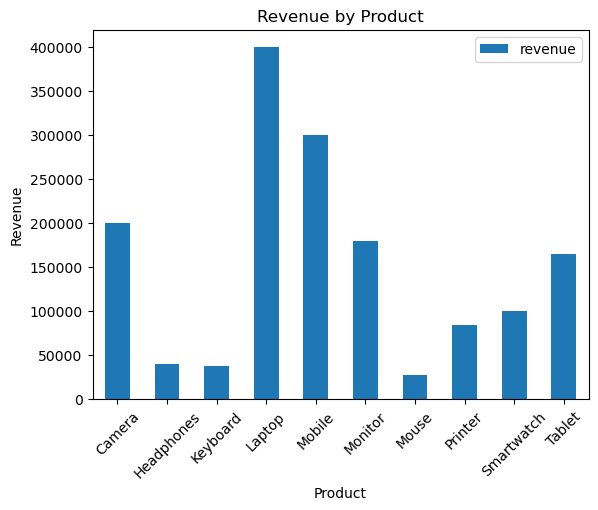

In [72]:
#ploting of the data using bar chart
df.plot(kind='bar', x='product', y='revenue')

plt.title("Revenue by Product")
plt.ylabel("Revenue")
plt.xlabel("Product")
plt.xticks(rotation=45)
plt.savefig("sales_chart.png")
plt.show()

In [48]:
conn.close()